In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import requests

from io import StringIO

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
import Estrategia
importlib.reload(Estrategia)
import Backtest
importlib.reload(Backtest)
from Backtest import *

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

EstrategiaMLEquiponderada = Estrategia.EstrategiaMLEquiponderada
EstrategiaMLMinVarAlphaTilt = Estrategia.EstrategiaMLMinVarAlphaTilt
EstrategiaMLMonteCarlo = Estrategia.EstrategiaMLMonteCarlo
EstrategiaMLEquiponderadaMacro = Estrategia.EstrategiaMLEquiponderadaMacro

### Descarga de tickers actuales del STOXX50

In [3]:
def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    headers = {"User-Agent": "Mozilla/5.0 ..."}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text), flavor='bs4')
    df = next(t for t in tables if 'Ticker' in t.columns)
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()

# Modelo elegido: XGBoost con estrategia de optimización de pesos por Montecarlo

[Train] 2018-12-28 → 2022-12-23 | AUC=0.5353 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 250, 'scale_pos_weight': 3, 'subsample': 0.7}
2023-01-06 | VP=10000000 | pesos={'AI.PA': 0.039924511252437886, 'ASML.AS': 0.036856972733832837, 'BAYN.DE': 0.03784907483066011, 'DHL.DE': 0.03350134361514107, 'DTE.DE': 0.19127470354377277, 'ENI.MI': 0.09014281731322595, 'IFX.DE': 0.03102125227272201, 'MUV2.DE': 0.19127470354377277, 'NOKIA.HE': 0.06661852439413343, 'RACE.MI': 0.02909707587946378, 'RHM.DE': 0.09315641761428531, 'SAP.DE': 0.04940584608580166, 'STLAM.MI': 0.02578999829848142, 'SU.PA': 0.04804286298636062, 'VOW.DE': 0.036043895635908166}
2023-01-13 | VP=10282738 | pesos={'ADYEN.AS': 0.026616574454776457, 'ASML.AS': 0.025150816549463446, 'BAYN.DE': 0.027226976949408326, 'DHL.DE': 0.049300664179577805, 'DTE.DE': 0.15084739343542702, 'EL.PA': 0.12249511172404225, 'ENI.MI': 0.09506829238312607, 'NDA-FI.HE': 0.15112315735980159, 'NOKIA.HE': 0.034081130422

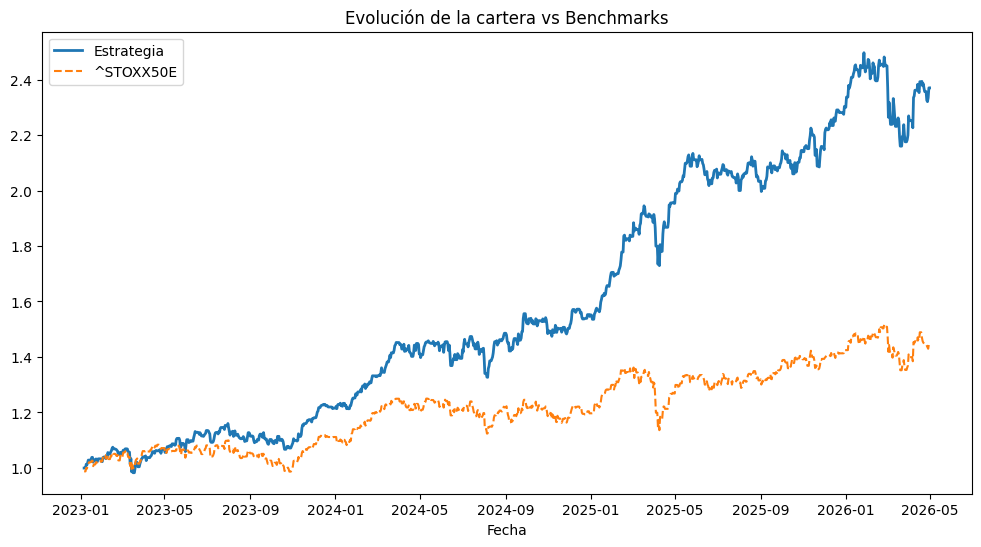

,Estrategia,^STOXX50E
Rentabilidad total,137.12%,46.39%
Rentabilidad anualizada,19.68%,8.25%
Volatilidad anualizada,13.78%,12.69%
Sharpe,1.37,0.69
Sortino,2.04,0.98
Max Drawdown,-13.49%,-16.58%
Calmar,1.46,0.50
Win rate,38.81%,36.25%
Mejor periodo,4.89%,4.97%
Peor periodo,-4.58%,-4.81%


In [3]:
start_date = "2023-01-03"
end_date = "2026-05-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=50000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

In [7]:
import numpy as np
from matplotlib.ticker import FuncFormatter
from IPython.display import display
from auxiliary_functions import build_metrics_table

start_date = "2023-01-03"
end_date = "2026-05-01"
nominal = 10_000_000

universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)
proveedor = YFinanceProvider()


def serie_backtest(engine, nombre):
    s = engine._run().set_index("Fecha")["Valor cartera"].sort_index()
    return (s / s.iloc[0]).rename(nombre)


def serie_benchmark(proveedor, ticker, fechas, nombre):
    df = proveedor.download_prices_daily(
        [ticker],
        fechas.min().strftime("%Y-%m-%d"),
        fechas.max().strftime("%Y-%m-%d"),
    )
    s = (
        df[df["Ticker"].eq(ticker)]
        .set_index("Fecha")["Precio_Close"]
        .sort_index()
        .reindex(fechas)
        .ffill()
    )
    return (s / s.iloc[0]).rename(nombre)


# 1) Modelo actual: XGBoost + MonteCarlo
fe_xgb = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo_xgb = XGBoostModel(random_state=42, n_splits=3)
estrategia_xgb_mc = EstrategiaMLMonteCarlo(
    modelo=modelo_xgb,
    n_activos_obj=15,
    umbral_salida=22,
    n_simulaciones=50000,
    peso_min=0.02,
    peso_max=0.15,
)

engine_xgb_mc = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe_xgb,
    estrategia=estrategia_xgb_mc,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=nominal,
)

serie_xgb_mc = serie_backtest(engine_xgb_mc, "XGBoost + MC")


# 2) Modelo adicional: RandomForest + pesos equiponderados
fe_rf = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo_rf = RandomForestModel(random_state=42, n_splits=3)
estrategia_rf_ew = EstrategiaMLEquiponderada(
    modelo=modelo_rf,
    n_activos_obj=15,
    umbral_salida=22,
)

engine_rf_ew = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe_rf,
    estrategia=estrategia_rf_ew,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=nominal,
)

serie_rf_ew = serie_backtest(engine_rf_ew, "RF + pesos EW")


# 3) Benchmark STOXX 50
serie_stoxx = serie_benchmark(
    proveedor=proveedor,
    ticker="^STOXX50E",
    fechas=serie_xgb_mc.index,
    nombre="STOXX 50",
)


# 4) Series finales alineadas
series_bt = pd.concat([serie_xgb_mc, serie_rf_ew, serie_stoxx], axis=1).ffill().dropna()

[Train] 2018-12-28 → 2022-12-23 | AUC=0.5353 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 250, 'scale_pos_weight': 3, 'subsample': 0.7}
2023-01-06 | VP=10000000 | pesos={'AI.PA': 0.036735164081273086, 'ASML.AS': 0.03883051653669241, 'BAYN.DE': 0.023095845803762907, 'DHL.DE': 0.025197813992082273, 'DTE.DE': 0.1468609706860807, 'ENI.MI': 0.1086162404444296, 'IFX.DE': 0.11534649853760727, 'MUV2.DE': 0.1373764624480218, 'NOKIA.HE': 0.03704572962816849, 'RACE.MI': 0.04848695361274165, 'RHM.DE': 0.03846924101400777, 'SAP.DE': 0.08067790906899809, 'STLAM.MI': 0.11561095348316577, 'SU.PA': 0.025850510204799643, 'VOW.DE': 0.021799190458168513}
2023-01-13 | VP=10282510 | pesos={'ADYEN.AS': 0.036735164081273086, 'ASML.AS': 0.03883051653669241, 'BAYN.DE': 0.023095845803762907, 'DHL.DE': 0.025197813992082273, 'DTE.DE': 0.1468609706860807, 'EL.PA': 0.1086162404444296, 'ENI.MI': 0.11534649853760727, 'NDA-FI.HE': 0.1373764624480218, 'NOKIA.HE': 0.03704572962816849

C:\Users\Deportivo Estadio\AppData\Local\Temp\ipykernel_16360\1279919906.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


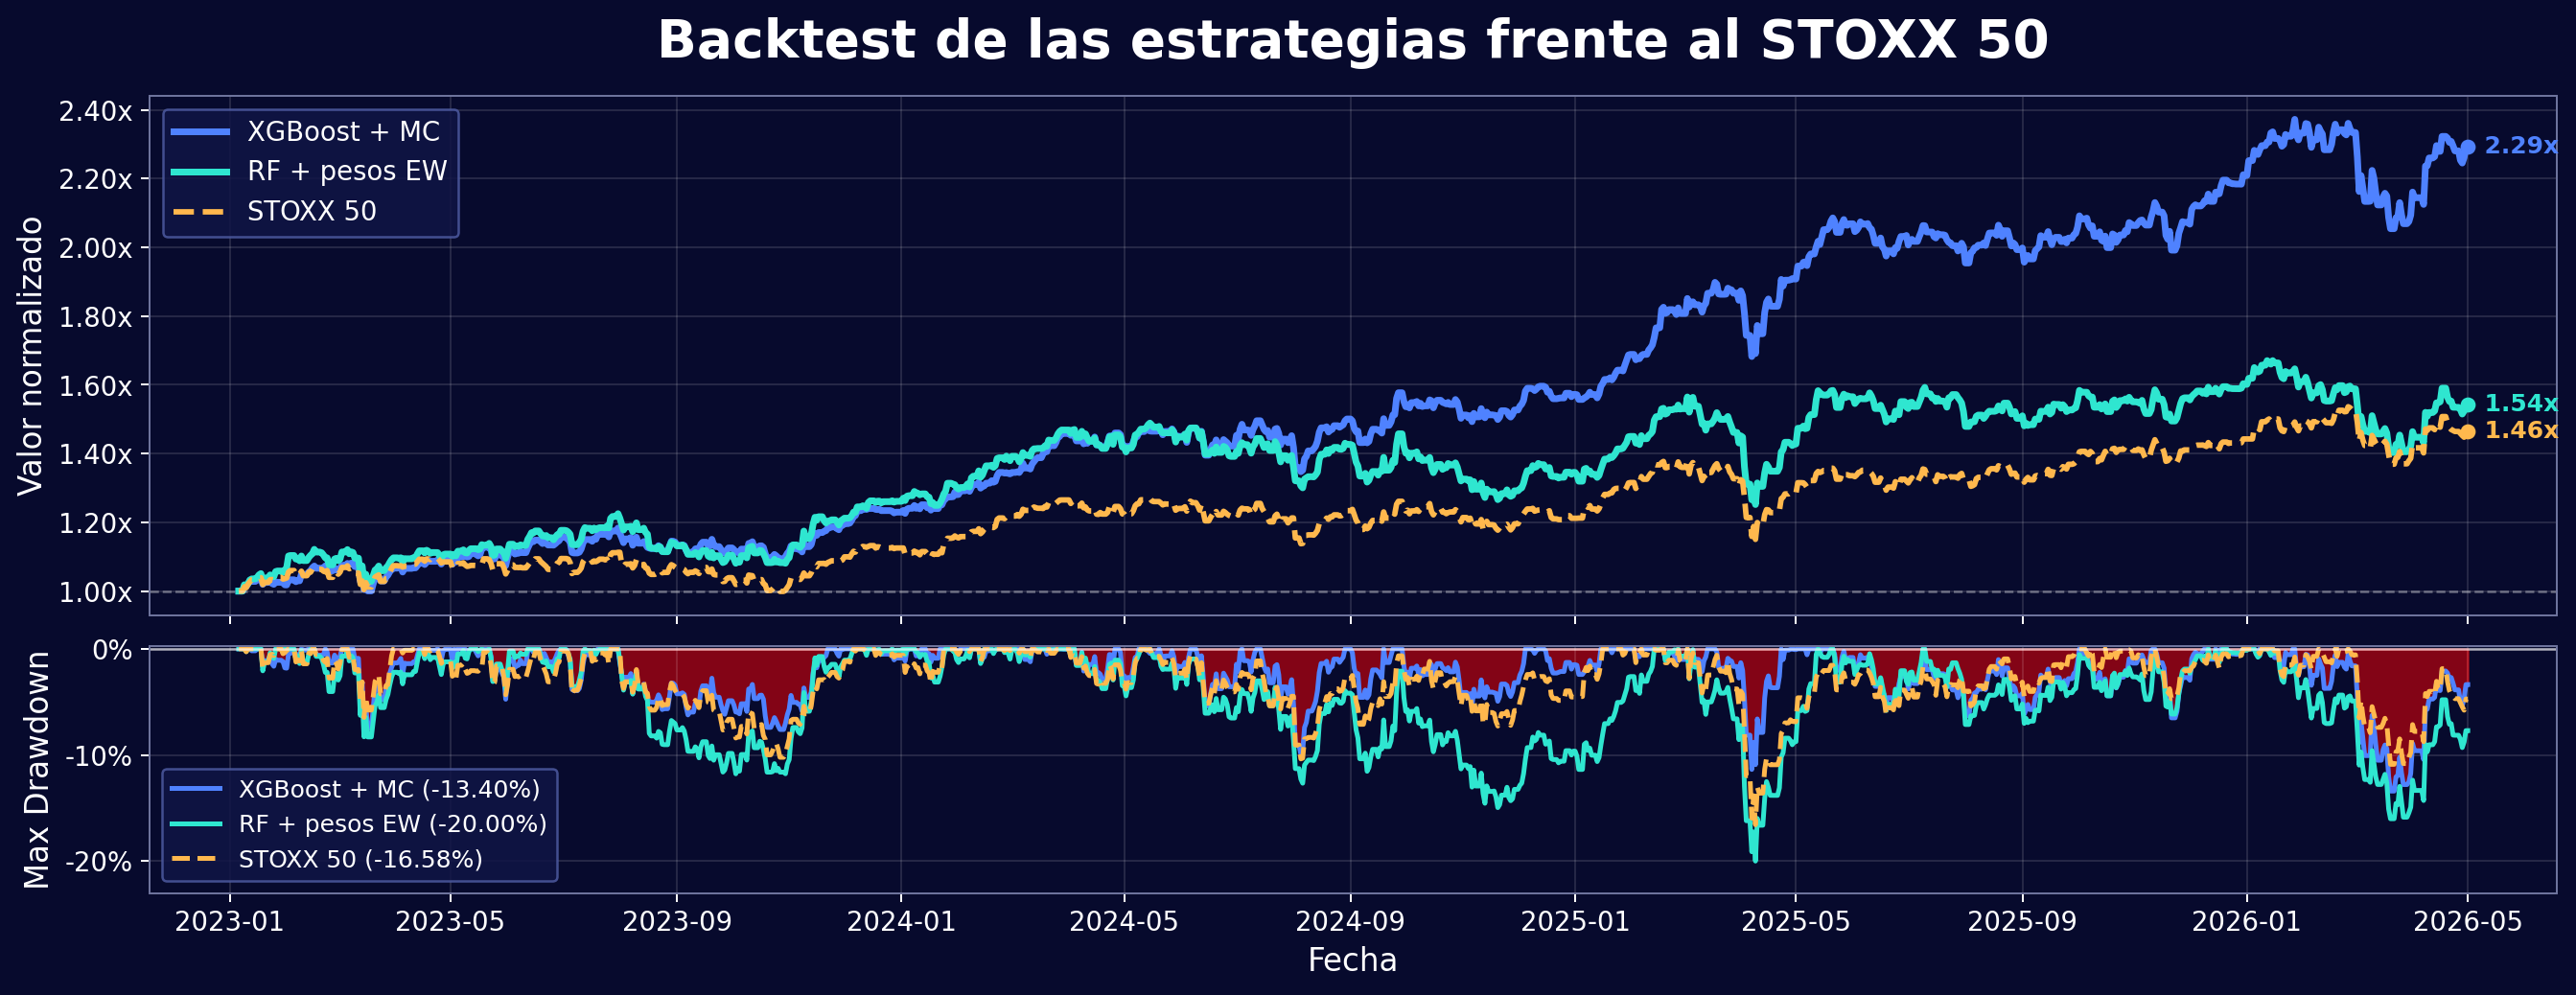

In [28]:
def grafico_backtests_slide(series, titulo="Backtest comparativo"):
    fondo = "#070A2D"
    colores = {
        "XGBoost + MC": "#4F82FF",
        "RF + pesos EW": "#2FE6D0",
        "STOXX 50": "#FFB84D",
    }

    dd = series / series.cummax() - 1

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(18, 6),
        dpi=180,
        sharex=True,
        gridspec_kw={"height_ratios": [2.1, 1], "hspace": 0.08}
    )

    fig.patch.set_facecolor(fondo)

    for ax in (ax1, ax2):
        ax.set_facecolor(fondo)
        ax.grid(True, color="white", alpha=0.12, linewidth=0.8)
        ax.tick_params(colors="white", labelsize=11)
        for s in ax.spines.values():
            s.set_color("#6D739C")

    for col in series.columns:
        color = colores.get(col, "white")
        estilo = "--" if col == "STOXX 50" else "-"
        lw = 2.8 if col != "STOXX 50" else 2.3

        ax1.plot(series.index, series[col], label=col, color=color, linewidth=lw, linestyle=estilo)
        ax1.scatter(series.index[-1], series[col].iloc[-1], color=color, s=28, zorder=3)
        ax1.text(
            series.index[-1],
            series[col].iloc[-1],
            f"  {series[col].iloc[-1]:.2f}x",
            color=color,
            fontsize=10,
            fontweight="bold",
            va="center",
        )

        ax2.plot(
            dd.index,
            dd[col],
            label=f"{col} ({dd[col].min():.2%})",
            color=color,
            linewidth=2.0,
            linestyle=estilo,
        )

    ax2.fill_between(
        dd.index,
        dd[series.columns[0]],
        0,
        color="#ff0000a7",
        alpha=0.50,
    )

    ax1.axhline(1, color="white", linestyle="--", linewidth=1, alpha=0.35)
    ax2.axhline(0, color="white", linewidth=1, alpha=0.65)

    ax1.set_title(titulo, color="white", fontsize=22, fontweight="bold", pad=16)
    ax1.set_ylabel("Valor normalizado", color="white", fontsize=13)
    ax2.set_ylabel("Max Drawdown", color="white", fontsize=13)
    ax2.set_xlabel("Fecha", color="white", fontsize=13)

    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}x"))
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax2.set_ylim(dd.min().min() * 1.15, 0.003)

    leg1 = ax1.legend(loc="upper left", frameon=True, fontsize=11)
    leg2 = ax2.legend(loc="lower left", frameon=True, fontsize=10)

    for leg in (leg1, leg2):
        leg.get_frame().set_facecolor("#101545")
        leg.get_frame().set_edgecolor("#4D5AA0")
        leg.get_frame().set_alpha(0.85)
        for t in leg.get_texts():
            t.set_color("white")

    ax1.margins(x=0.04)
    plt.tight_layout()
    plt.show()

    return fig, (ax1, ax2)

fig, (ax1, ax2) = grafico_backtests_slide(
    series_bt,
    titulo="Backtest de las estrategias frente al STOXX 50"
)

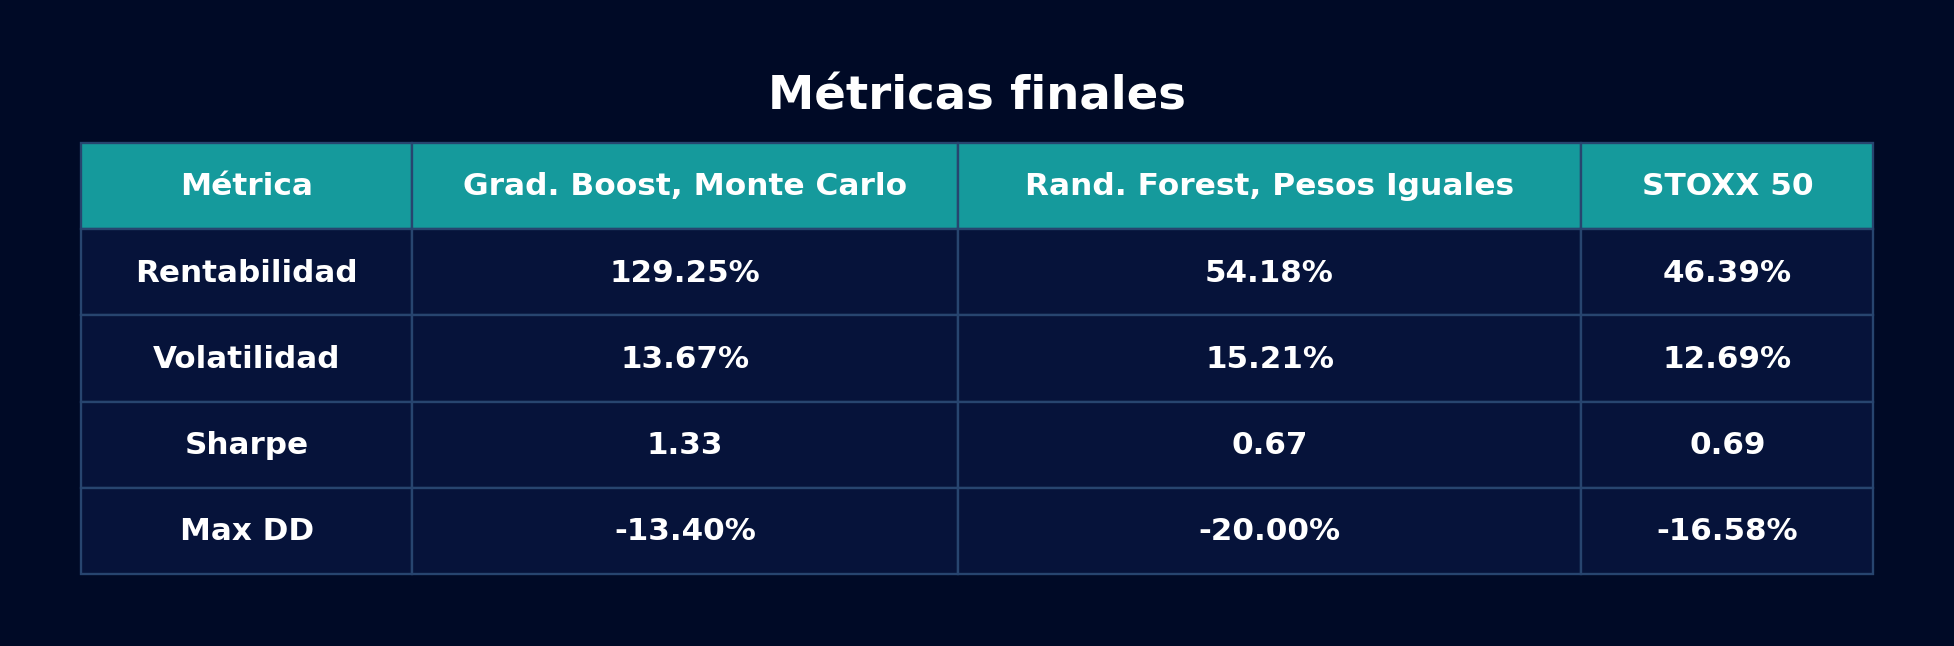

In [38]:
from auxiliary_functions import build_metrics_table
import matplotlib.pyplot as plt

tabla_metricas = build_metrics_table(
    {c: series_bt[c] for c in series_bt.columns},
    periods_per_year=252,
    rf_annual=0.0,
)

nombres_estrategias = {
    "XGBoost + MC": "Grad. Boost, Monte Carlo",
    "RF + pesos EW": "Rand. Forest, Pesos Iguales",
    "STOXX 50": "STOXX 50",
}

tabla_metricas = build_metrics_table(
    {c: series_bt[c] for c in series_bt.columns},
    periods_per_year=252,
    rf_annual=0.0,
).rename(index=nombres_estrategias)

tabla_slide = tabla_metricas[
    ["Rentabilidad total", "Volatilidad anualizada", "Sharpe", "Max Drawdown"]
].rename(columns={
    "Rentabilidad total": "Rentabilidad",
    "Volatilidad anualizada": "Volatilidad",
    "Max Drawdown": "Max DD",
})


tabla_slide = tabla_metricas[
    ["Rentabilidad total", "Volatilidad anualizada", "Sharpe", "Max Drawdown"]
].rename(columns={
    "Rentabilidad total": "Rentabilidad",
    "Volatilidad anualizada": "Volatilidad",
    "Max Drawdown": "Max DD",
})

def tabla_metricas_backtest_canva(tabla_slide, titulo="Métricas finales", guardar=None):
    df = tabla_slide.copy()

    df = df.T.astype(object)

    for fila in ["Rentabilidad", "Volatilidad", "Max DD"]:
        if fila in df.index:
            df.loc[fila] = df.loc[fila].map(lambda x: f"{float(x):.2%}")

    if "Sharpe" in df.index:
        df.loc["Sharpe"] = df.loc["Sharpe"].map(lambda x: f"{float(x):.2f}")

    df = df.reset_index().rename(columns={"index": "Métrica"})

    fondo = "#000A26"
    panel = "#06133A"
    header = "#159A9C"
    lineas = "#27456F"
    blanco = "#FFFFFF"

    n_cols = len(df.columns)
    fig_w = max(8, 1.25 * n_cols)
    fig_h = 2.55

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=240)
    fig.patch.set_facecolor(fondo)
    ax.set_facecolor(fondo)
    ax.axis("off")

    tabla = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.03, 0.08, 0.94, 0.72]
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9.4)
    tabla.scale(0.92, 1.45)

    anchos = {
        0: 0.17,  # Métrica
        1: 0.28,  # Grad. Boost y Monte Carlo
        2: 0.32,  # Random Forest y Equiponderación
        3: 0.15,  # STOXX 50
    }

    for (fila, col), celda in tabla.get_celld().items():
        celda.set_edgecolor(lineas)
        celda.set_linewidth(0.7)
        celda.set_width(anchos.get(col, 0.26))

        if fila == 0:
            celda.set_facecolor(header)
            celda.get_text().set_color(blanco)
            celda.get_text().set_weight("bold")
            celda.get_text().set_fontsize(9.4)
        else:
            celda.set_facecolor(panel)
            celda.get_text().set_color(blanco)
            celda.get_text().set_weight("bold")
            celda.get_text().set_fontsize(9.3)

    ax.text(
        0.5, 0.84,
        titulo,
        ha="center", va="bottom",
        color=blanco,
        fontsize=14,
        fontweight="bold",
        transform=ax.transAxes
    )

    plt.tight_layout(pad=0.2)

    if guardar:
        fig.savefig(guardar, dpi=300, bbox_inches="tight", facecolor=fondo)

    plt.show()
    return fig, ax

fig, ax = tabla_metricas_backtest_canva(
    tabla_slide,
    titulo="Métricas finales",
    guardar=None
)

In [ ]:
start_date = "2020-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
provider = YFinanceProvider()

bt_random = BacktestRandom(
    universo=universo,
    proveedor=provider,
    start_date="2022-01-01",
    end_date="2024-01-01",
    nominal=100000,
    n_activos=15
)

res = bt_random.run_montecarlo(
    n_sims=100,
    benchmark="^STOXX50E"
)

plt.figure(figsize=(12, 6))
plt.plot(res["media"].index, res["media"] / res["media"].iloc[0], label="Media 100 simulaciones", linewidth=2)
plt.plot(res["benchmark"].index, res["benchmark"] / res["benchmark"].iloc[0], label="EuroStoxx 50", linestyle="--")
plt.title("Backtest aleatorio vs EuroStoxx 50")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(True)
plt.show()

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr

[Train] 2009-01-09 → 2015-01-02 | AUC=0.5362 | {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 5, 'subsample': 0.7}
2015-01-09 | VP=10000000 | pesos={'ARGX.BR': 0.06304400086546466, 'ASML.AS': 0.15966368497038919, 'BAYN.DE': 0.10020254030539232, 'BBVA.MC': 0.042867132070472, 'BNP.PA': 0.03395453904054303, 'ENEL.MI': 0.06193894635690152, 'ENI.MI': 0.028278120838474807, 'RHM.DE': 0.04642574232041499, 'SAN.MC': 0.03194248378439305, 'SAN.PA': 0.11124389589138288, 'STLAM.MI': 0.12377244127269058, 'TEF.MC': 0.02794775934602701, 'TTE.PA': 0.02643189195323377, 'UCG.MI': 0.030137649565251487, 'VOW.DE': 0.11214917141896881}
2015-01-16 | VP=10524434 | pesos={'AD.AS': 0.035462716488534364, 'ARGX.BR': 0.16399473756537136, 'ASML.AS': 0.16399473756537136, 'BNP.PA': 0.04518983502808019, 'ENEL.MI': 0.029172719021798275, 'ENGI.PA': 0.03379243416290679, 'ENI.MI': 0.054615674246737786, 'IBE.MC': 0.07598574942698932, 'RHM.DE': 0.026484288045131005, 

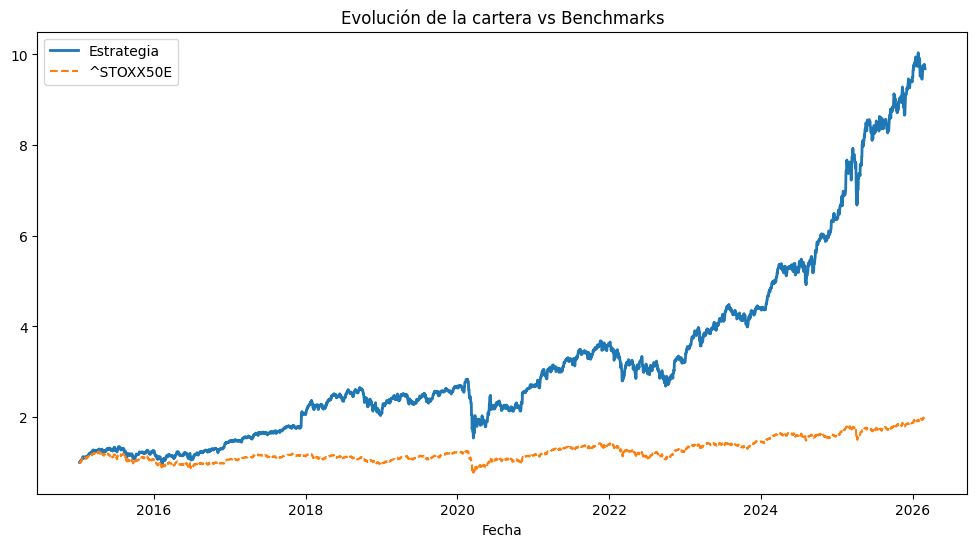

,Estrategia,^STOXX50E
Rentabilidad total,868.39%,101.73%
Rentabilidad anualizada,15.10%,4.44%
Volatilidad anualizada,19.38%,15.67%
Sharpe,0.82,0.36
Sortino,1.18,0.49
Max Drawdown,-45.82%,-38.27%
Calmar,0.33,0.12
Win rate,38.54%,36.67%
Mejor periodo,13.01%,9.24%
Peor periodo,-15.55%,-12.40%


In [5]:
start_date = "2015-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

$STM.MI: possibly delisted; no timezone found

1 Failed download:
['STM.MI']: possibly delisted; no timezone found
$STM.MI: possibly delisted; no timezone found

1 Failed download:
['STM.MI']: possibly delisted; no timezone found
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in

[Train] 2004-01-09 → 2010-01-01 | AUC=0.5156 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2010-01-08 | VP=10000000 | pesos={'ASML.AS': 0.15115233044519086, 'BAS.DE': 0.061616573552227646, 'BBVA.MC': 0.14497329023373126, 'CS.PA': 0.02366017329348456, 'DBK.DE': 0.02598076312757706, 'IBE.MC': 0.07105784025165271, 'MBG.DE': 0.03374612710495384, 'MC.PA': 0.07519379702287629, 'OR.PA': 0.059906332506551904, 'RHM.DE': 0.039909786662112264, 'RNO.PA': 0.036079238075769286, 'SAN.MC': 0.15115233044519086, 'STLAM.MI': 0.059746975053450606, 'SU.PA': 0.0429697189877668, 'VOW.DE': 0.022854723237464094}
2010-01-15 | VP=9780040 | pesos={'ADS.DE': 0.14253549878185268, 'ASML.AS': 0.11304629225423965, 'BAS.DE': 0.041705996552072036, 'BBVA.MC': 0.1181787585308085, 'DBK.DE': 0.02483202637835564, 'DHL.DE': 0.03891163873545156, 'IFX.DE': 0.06258712495699346, 'MC.PA': 0.08233609226597444, 'OR.PA': 0.05582969903035395, 'RHM.DE': 

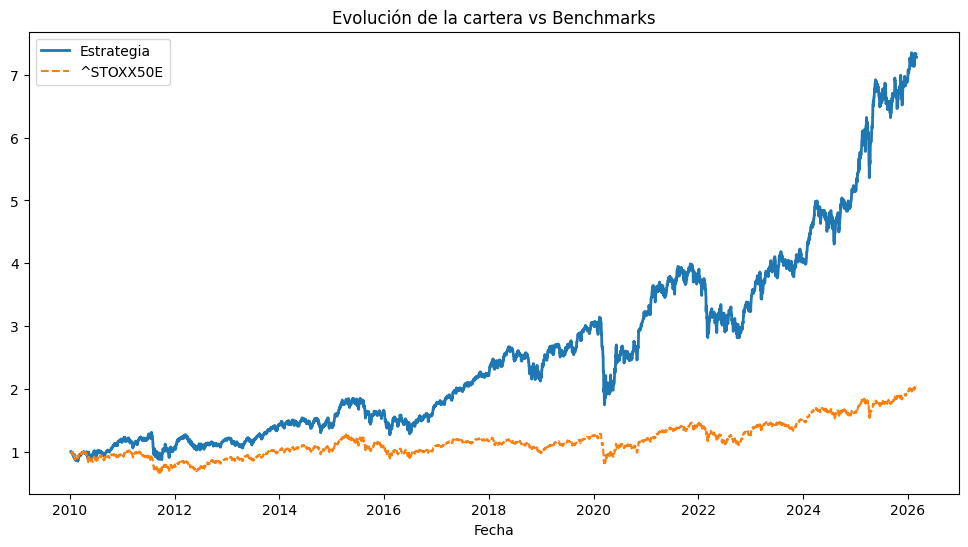

,Estrategia,^STOXX50E
Rentabilidad total,627.80%,103.40%
Rentabilidad anualizada,8.85%,3.08%
Volatilidad anualizada,19.87%,16.59%
Sharpe,0.53,0.27
Sortino,0.75,0.37
Max Drawdown,-44.52%,-38.27%
Calmar,0.20,0.08
Win rate,37.19%,36.02%
Mejor periodo,12.47%,10.35%
Peor periodo,-14.49%,-12.40%


In [ ]:
start_date = "2010-01-03"
end_date = "2026-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02, peso_max=0.15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])